# Column — interactive design notebook

Builds a reinforced-concrete column step by step, runs the P-M-M surface, lets you query results with chained access, and detail the confinement with full control over inputs.

**Internal unit system:** MPa, mm, kN, kN·m (formulas never change).
**Presentation units:** controlled by `col.set_units(...)` — ETABS codes 1..16 or names like `Tonf_mm_C`.

Launch Jupyter from the repo root (`EtabsToPython/`).

## 1. Imports

In [1]:
import sys
from pathlib import Path

# Uncomment if Jupyter started outside the repo root:
# sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
# %matplotlib inline

from design import (
    Concrete, Steel, Bar,
    RectangularSection, Column, BarSchedule,
    to_internal, units_from,
)
from design.columns.column import ColumnDemands
from design.sections.reinforcement import RebarLayout, perimeter_bars

# Pick the unit system for INPUTS and DISPLAY.
# Internal numerics are always MPa, mm, kN — to_internal() converts.
INPUT_UNITS   = 9    # N_mm_C   — you enter Pu/Mu/Vu in N and N·mm
DISPLAY_UNITS = 12   # Tonf_m_C — plots, summary, report use Tonf and m

print(f'Input units   : {units_from(INPUT_UNITS).name}')
print(f'Display units : {units_from(DISPLAY_UNITS).name}')
print('Imports OK')

Imports OK


## 2. Materials

Always in MPa for stress and mm for length — the package will translate to your presentation units later.

In [2]:
concrete = Concrete(fc=21)          # MPa
steel    = Steel(fy=420, grade=60)  # MPa
bar      = Bar(diameter=22)         # longitudinal bar diameter, mm

print(f'fc      = {concrete.fc} MPa')
print(f'beta1   = {concrete.beta1:.3f}')
print(f'Ec      = {concrete.Ec:.0f} MPa')
print(f'lambda  = {concrete.lam}')
print(f'fy      = {steel.fy} MPa')
print(f'eps_ty  = {steel.eps_ty:.5f}')
print(f'bar dia = {bar.diameter} mm  (area = {bar.area:.1f} mm²)')

fc      = 21 MPa
beta1   = 0.850
Ec      = 21538 MPa
lambda  = 1.0
fy      = 420 MPa
eps_ty  = 0.00210
bar dia = 22 mm  (area = 380.1 mm²)


## 3. Geometry + reinforcement

| Variable | Meaning |
|---|---|
| `b` | section width (mm) — local X axis |
| `h` | section height (mm) — local Y axis |
| `cover` | cover to bar centroid (mm) |
| `n_x` | bars on **each** horizontal edge |
| `n_y` | bars on **each** vertical edge |

Total bars: `2*n_x + 2*n_y - 4` (corners deduplicated).

In [3]:
# === EDIT THESE LINES ===
b = 40*10        # mm
h = 80*10       # mm
cover = 50.0     # mm
n_x = 4          # bars on each horizontal edge
n_y = 5         # bars on each vertical edge
# ========================

group = perimeter_bars(
    b=b, h=h, cover=cover,
    n_x=n_x, n_y=n_y,
    bar=bar, steel=steel,
)
section = RectangularSection(
    b=b, h=h, concrete=concrete,
    rebar=RebarLayout(groups=(group,)),
)

n_total = group.n
Ast = group.total_area
Ag = section.gross_area()
print(f'Total bars = {n_total}')
print(f'As_total   = {Ast:.0f} mm² ({n_total} × {bar.area:.0f})')
print(f'Ag         = {Ag:.0f} mm²')
print(f'rho        = {Ast/Ag*100:.2f}%   (ACI §10.6.1.1: 1% – 8%; SMF §18.7.4.1: 1% – 6%)')

Total bars = 14
As_total   = 5322 mm² (14 × 380)
Ag         = 320000 mm²
rho        = 1.66%   (ACI §10.6.1.1: 1% – 8%; SMF §18.7.4.1: 1% – 6%)


## 4. Build the Column

All Column constructor inputs:

| arg | meaning | default |
|---|---|---|
| `section` | RectangularSection (or any Section subclass) | — required |
| `lu` | unbraced length (m) | — required |
| `k` | effective length factor | `1.0` |
| `spiral` | spiral hoops (vs ties) | `False` |
| `Av` | transverse area used by capacity() shear | `0.0` |
| `fyt` | hoop yield strength (MPa) | `420.0` |
| `s` | hoop spacing (mm) used in capacity() | `None` |
| `seismic` | SMF detailing rules apply | `True` |
| `hx` | max lateral spacing of supported bars (mm) | `200.0` |
| `h_min` | min cross-sectional dimension (mm) | `section.width()` |
| `transverse_bar_diameter` | default hoop diameter (mm) | `10.0` |
| `units` | presentation units (code 1..16 or name) | `kN_mm_C` |
| `bar_schedule` | preferred bar diameters | sensible defaults |
| `label` | human-friendly tag | `'Column'` |
| `run_settings` | persistent kwargs for run() | `{n_angles: 37, n_points: 60}` |

In [4]:
column = Column(
    section=section,
    lu=3000.0,                       # m
    k=1.0,
    spiral=False,
    Av=2 * 71.0,                  # 2 legs φ10 — placeholder for capacity() shear
    fyt=420.0,
    s=100.0,
    seismic=True,
    hx=150.0,
    transverse_bar_diameter=10.0,
    label='Col-1A',
)
column.set_units(DISPLAY_UNITS)
column

Column(label='Col-1A', section=400×800 mm, fc=21 MPa, units=kN_mm_C, run=no)

## 5. Set presentation units (ETABS codes)

Pass the ETABS numerical code or a string name. Internal numerics stay in MPa, mm, kN.

| Code | Force | Length |  | Code | Force | Length |
|---:|---|---|---|---:|---|---|
| 1 | lb | in | | 9 | N | mm |
| 2 | lb | ft | | 10 | N | m |
| 3 | kip | in | | 11 | Tonf | mm |
| 4 | kip | ft | | 12 | Tonf | m |
| 5 | kN | mm | | 13 | kN | cm |
| 6 | kN | m  | | 14 | kgf | cm |
| 7 | kgf | mm | | 15 | N | cm |
| 8 | kgf | m | | 16 | Tonf | cm |

In [5]:
# Already set in cell 4 to DISPLAY_UNITS. You can change it anytime:
column.set_units(DISPLAY_UNITS)

print(f'units code  = {column.units.code}')
print(f'units name  = {column.units.name}')
print(f'force_factor (kN  → {column.units.force})  = {column.units.force_factor:.6f}')
print(f'length_factor (mm → {column.units.length}) = {column.units.length_factor}')
print(f'moment_factor (kN·m → {column.units.force}·{column.units.length}) = {column.units.moment_factor:.4f}')

# Reverse direction — to_internal helpers:
print()
print('Reverse — value in display units → internal:')
print(f'  1 {column.units.force}   →  {column.units.to_internal_force(1):.4f} kN')
print(f'  1 {column.units.length}  →  {column.units.to_internal_length(1):.0f} mm')
print(f'  1 {column.units.force}·{column.units.length}  →  {column.units.to_internal_moment(1):.4f} kN·m')

units code  = 11
units name  = Tonf_mm_C
force_factor (kN  → Tonf)  = 0.101972
length_factor (mm → mm) = 1.0
moment_factor (kN·m → Tonf·mm) = 101.9716


## 6. Run — build the P-M-M surface

`col.run()` computes the interaction surface and caches it. All the scalars (`col.Po`, `col.To`, `col.phi_Pn_max`, `col.phi_Vn`) and the proxies (`col.Mn`, `col.phi_Mn`, …) become available afterwards.

Args (both optional, fall back to `col.run_settings`):

| arg | meaning |
|---|---|
| `n_angles` | curves swept on 0..180°; 37 → 5° step, 73 → 2.5° |
| `n_points` | sampling per curve (the `c` sweep) |

Tip: set `column.run_settings = {'n_angles': 73, 'n_points': 80}` if you always want high-res.

In [6]:
import time
t0 = time.perf_counter()
column.run(n_angles=37, n_points=60)
dt = time.perf_counter() - t0
print(f'run() built the surface in {dt*1000:.0f} ms')

run() built the surface in 207 ms


## 7. Summary — column state in current units

In [7]:
column.summary()

=== Col-1A ===  (units: Tonf_mm_C)
Section : 400×800 mm
Materials: fc = 21 MPa, fy = 420 MPa
Rebar   : 14 bars, As = 5321.9 mm², ρ = 1.66%
Po      : 801 Tonf
To      : -228 Tonf
φPn,max : 416 Tonf
φVn     : 50 Tonf
max φMn @ θ=0°  : 90462.8 Tonf·mm
max φMn @ θ=90° : 42535.2 Tonf·mm


## 8. Surface — direct access to PMM curves and slices

`col.surface` behaves like a mapping `{theta_deg → InteractionDiagram}` plus helpers.

Convention: θ=0° → bending around X axis (Mxx). θ=90° → bending around Y axis (Myy).

In [8]:
print(f'available angles = {column.surface.angles}')
print(f'n_angles         = {len(column.surface)}')

diag0 = column.surface[0]         # diagram at θ=0
diag90 = column.surface[90]       # diagram at θ=90
print(f'max phi_Mn @ 0°  = {max(diag0.phi_Mn):.1f} kN·m (Mxx)')
print(f'max phi_Mn @ 90° = {max(diag90.phi_Mn):.1f} kN·m (Myy)')

# Biaxial envelope at a chosen Pu
mx, my = column.surface.at_Pu(2000.0)
print(f'envelope at Pu=2000 kN: {len(mx)} points, Mx in [{mx.min():.0f}, {mx.max():.0f}]')

# Sample the whole volume
Pu_grid, Mx_grid, My_grid = column.surface.volume(n_Pu=20)
print(f'volume grid shape = {Mx_grid.shape}  (Pu slices, theta points)')

# Biaxial 3D check
ok, ratio = column.surface.check(Pu=2500, Mux=200, Muy=120)
print(f'3D check Pu=2500, Mux=200, Muy=120 → ratio = {ratio:.3f}, passed = {ok}')

available angles = [  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  65.
  70.  75.  80.  85.  90.  95. 100. 105. 110. 115. 120. 125. 130. 135.
 140. 145. 150. 155. 160. 165. 170. 175. 180.]
n_angles         = 37
max phi_Mn @ 0°  = 887.1 kN·m (Mxx)
max phi_Mn @ 90° = 417.1 kN·m (Myy)
envelope at Pu=2000 kN: 74 points, Mx in [-689, 689]
volume grid shape = (20, 74)  (Pu slices, theta points)
3D check Pu=2500, Mux=200, Muy=120 → ratio = 0.432, passed = True


## 9. Result-view proxies (`col.Mn`, `col.phi_Mn`, `col.Pn`, `col.phi_Pn`)

Each proxy supports:

```python
col.Mn(angle=0)              # full curve as np.ndarray (kN·m, internal)
col.Mn.at(Pu=0, angle=0)     # scalar interpolated at Pu=0
col.Mn.peak(angle=0)         # max(Mn) at one angle (balanced moment)
col.Mn.peak()                # max(Mn) over ALL angles
col.Mn[0]                    # == col.Mn(angle=0)
col.Mn[0, 2500]              # == col.Mn.at(angle=0, Pu=2500)
```

All numbers are in internal units (kN·m for Mn, kN for Pn). Multiply by `col.units.moment_factor` / `force_factor` for display.

In [9]:
curve_Mn_at_0 = column.Mn(angle=0)
print(f'col.Mn(angle=0)               -> array of {curve_Mn_at_0.shape[0]} points')
print(f'col.Mn.at(Pu=0, angle=0)      = {column.Mn.at(Pu=0, angle=0):.1f} kN·m')
print(f'col.Mn.at(Pu=2500, angle=0)   = {column.Mn.at(Pu=2500, angle=0):.1f} kN·m')
print(f'col.Mn.peak(angle=0)          = {column.Mn.peak(angle=0):.1f} kN·m  (balanced @ θ=0)')
print(f'col.Mn.peak()                 = {column.Mn.peak():.1f} kN·m  (any angle)')
print()
print(f'col.phi_Mn.at(Pu=0, angle=0)  = {column.phi_Mn.at(Pu=0, angle=0):.1f} kN·m')
print(f'col.phi_Mn.peak()             = {column.phi_Mn.peak():.1f} kN·m')
print()
print(f'col.Mn[0]   -> same as col.Mn(angle=0), shape {column.Mn[0].shape}')
print(f'col.Mn[0, 2500]               = {column.Mn[0, 2500]:.1f} kN·m')
print()
print(f'col.Po           = {column.Po:.0f} kN')
print(f'col.To           = {column.To:.0f} kN')
print(f'col.phi_Pn_max   = {column.phi_Pn_max:.0f} kN')
print(f'col.phi_Vn       = {column.phi_Vn:.0f} kN')

col.Mn(angle=0)               -> array of 60 points
col.Mn.at(Pu=0, angle=0)      = 755.1 kN·m
col.Mn.at(Pu=2500, angle=0)   = 1075.1 kN·m
col.Mn.peak(angle=0)          = 1078.6 kN·m  (balanced @ θ=0)
col.Mn.peak()                 = 1078.6 kN·m  (any angle)

col.phi_Mn.at(Pu=0, angle=0)  = 679.6 kN·m
col.phi_Mn.peak()             = 887.1 kN·m

col.Mn[0]   -> same as col.Mn(angle=0), shape (60,)
col.Mn[0, 2500]               = 1075.1 kN·m

col.Po           = 7852 kN
col.To           = -2235 kN
col.phi_Pn_max   = 4083 kN
col.phi_Vn       = 490 kN


## 10. Demand + check

Sign convention:
- **`Pu > 0`** → compression
- **`Mux`** = moment about local X (bending around X)
- **`Muy`** = moment about local Y (bending around Y)

In [10]:
# Inputs as they would arrive from a force tracker — code 9 (N, mm).
# Same numerical figures as before but expressed in N and N·mm.
Pu_input  = 250_000          # N
Mux_input = 20_000_000       # N·mm
Muy_input = 12_000_000       # N·mm
Vux_input = 15_000           # N

# Convert to internal once. The kind of value tells the helper how to scale.
Pu  = to_internal('force',  Pu_input,  units=INPUT_UNITS)
Mux = to_internal('moment', Mux_input, units=INPUT_UNITS)
Muy = to_internal('moment', Muy_input, units=INPUT_UNITS)
Vux = to_internal('force',  Vux_input, units=INPUT_UNITS)

print(f'Pu  = {Pu_input} N         → {Pu:.1f} kN')
print(f'Mux = {Mux_input} N·mm     → {Mux:.1f} kN·m')
print(f'Vux = {Vux_input} N        → {Vux:.1f} kN')

demands = ColumnDemands(Pu=Pu, Mux=Mux, Muy=Muy, Vux=Vux, Vuy=0.0)

chk = column.check(demands)
print()
print(f'ratio PMM    = {chk.ratio_pmm:.3f}')
print(f'ratio shear  = {chk.ratio_shear:.3f}')
print(f'passed       = {chk.passed}')

ratio PMM    = 0.037
ratio shear  = 0.031
passed       = True


## 11. Plot — section

All plotting goes through `col.plot.*`. Styles live in `col.plot.style` (PlotStyle dataclass).

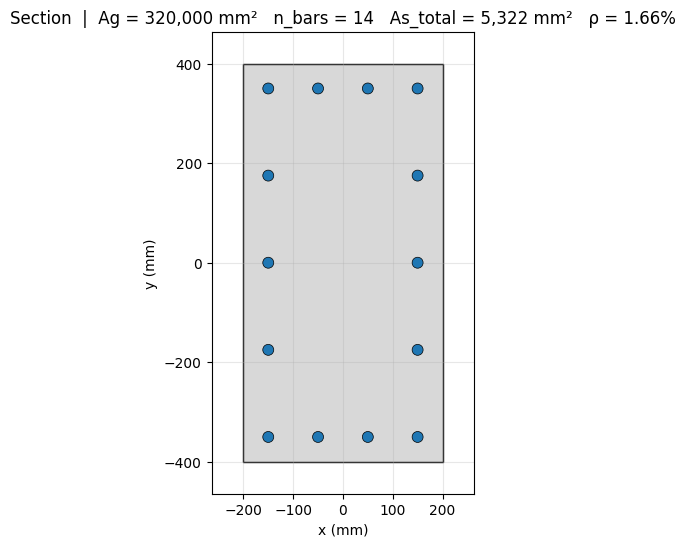

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
column.plot.section(ax=ax)
plt.show()

## 12. Plot — P-M at any angle

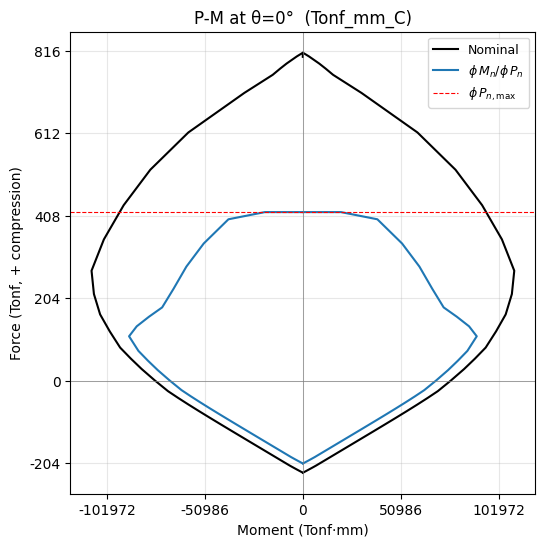

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
column.plot.pm(angle=0, ax=ax)
plt.show()

### 12b. Plot — compare several angles

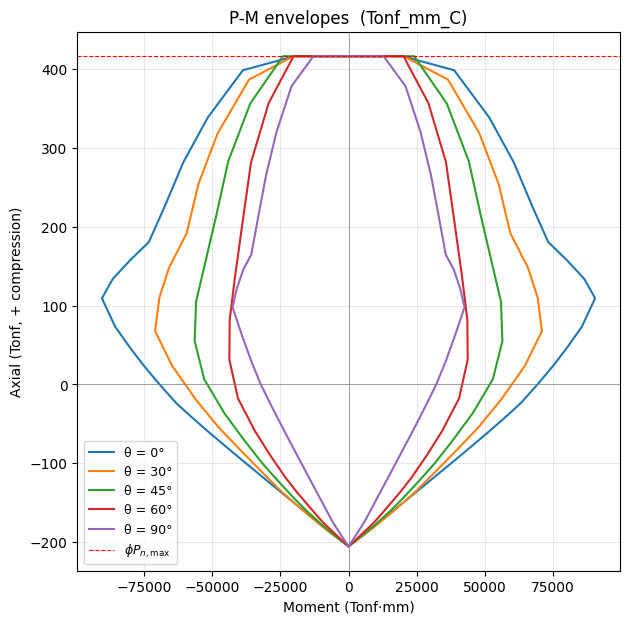

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))
column.plot.pm_compare(angles=[0, 30, 45, 60, 90], ax=ax)
plt.show()

## 13. Plot — P-M-M volume (3D)

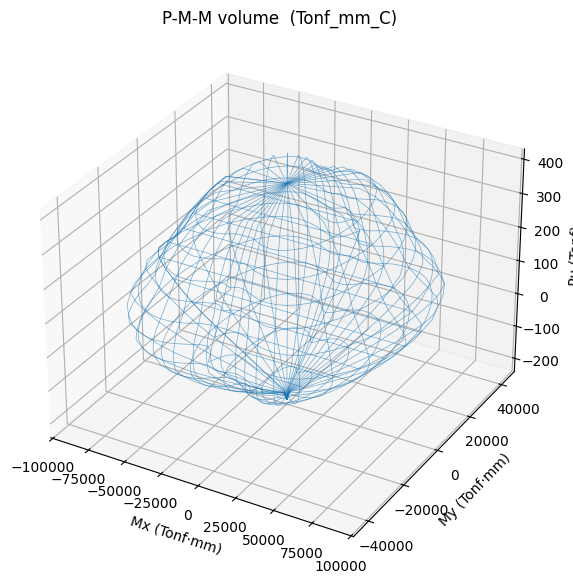

In [14]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
column.plot.pmm_volume(ax=ax, n_Pu=25)
plt.show()

## 14. Plot — biaxial slice with demand

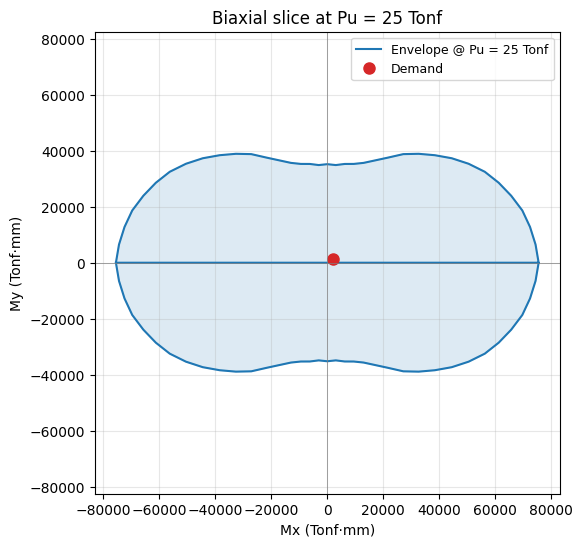

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
column.plot.pmm_slice(Pu=demands.Pu,
                      demand=(demands.Mux, demands.Muy),
                      ax=ax)
plt.show()

## 15. Plot — volume + demand (3D)

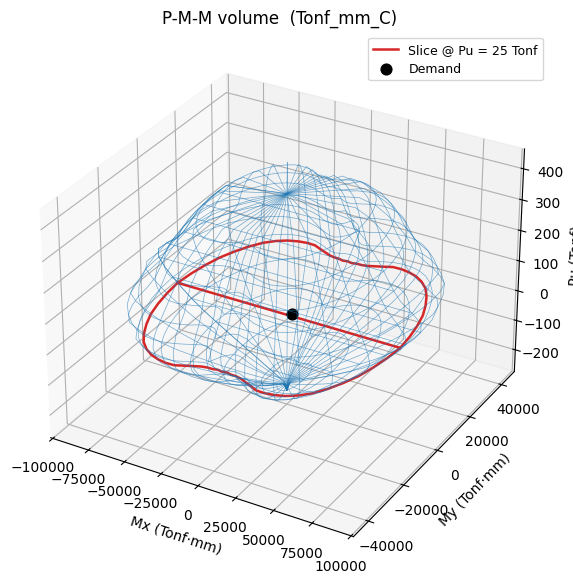

In [16]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
column.plot.pmm_with_demand(
    Pu=demands.Pu, Mux=demands.Mux, Muy=demands.Muy,
    ax=ax,
)
plt.show()

## 16. Plot — demand check shorthand

Combines slice + demand + the ratio in the title.

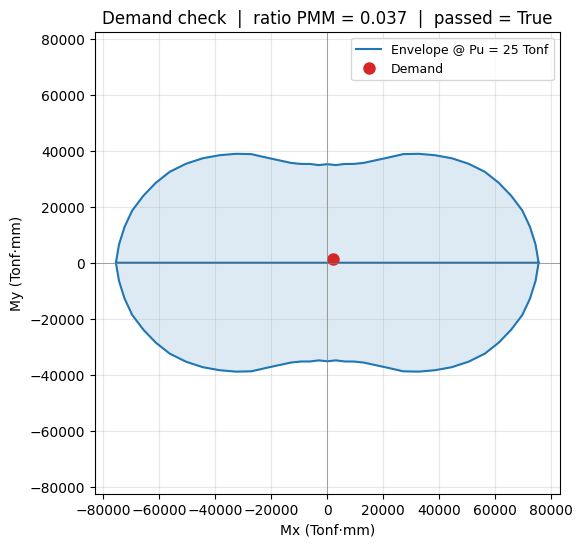

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))
column.plot.demand(demands, ax=ax)
plt.show()

## 17. Plot — dashboard (section + P-M + volume + demand)

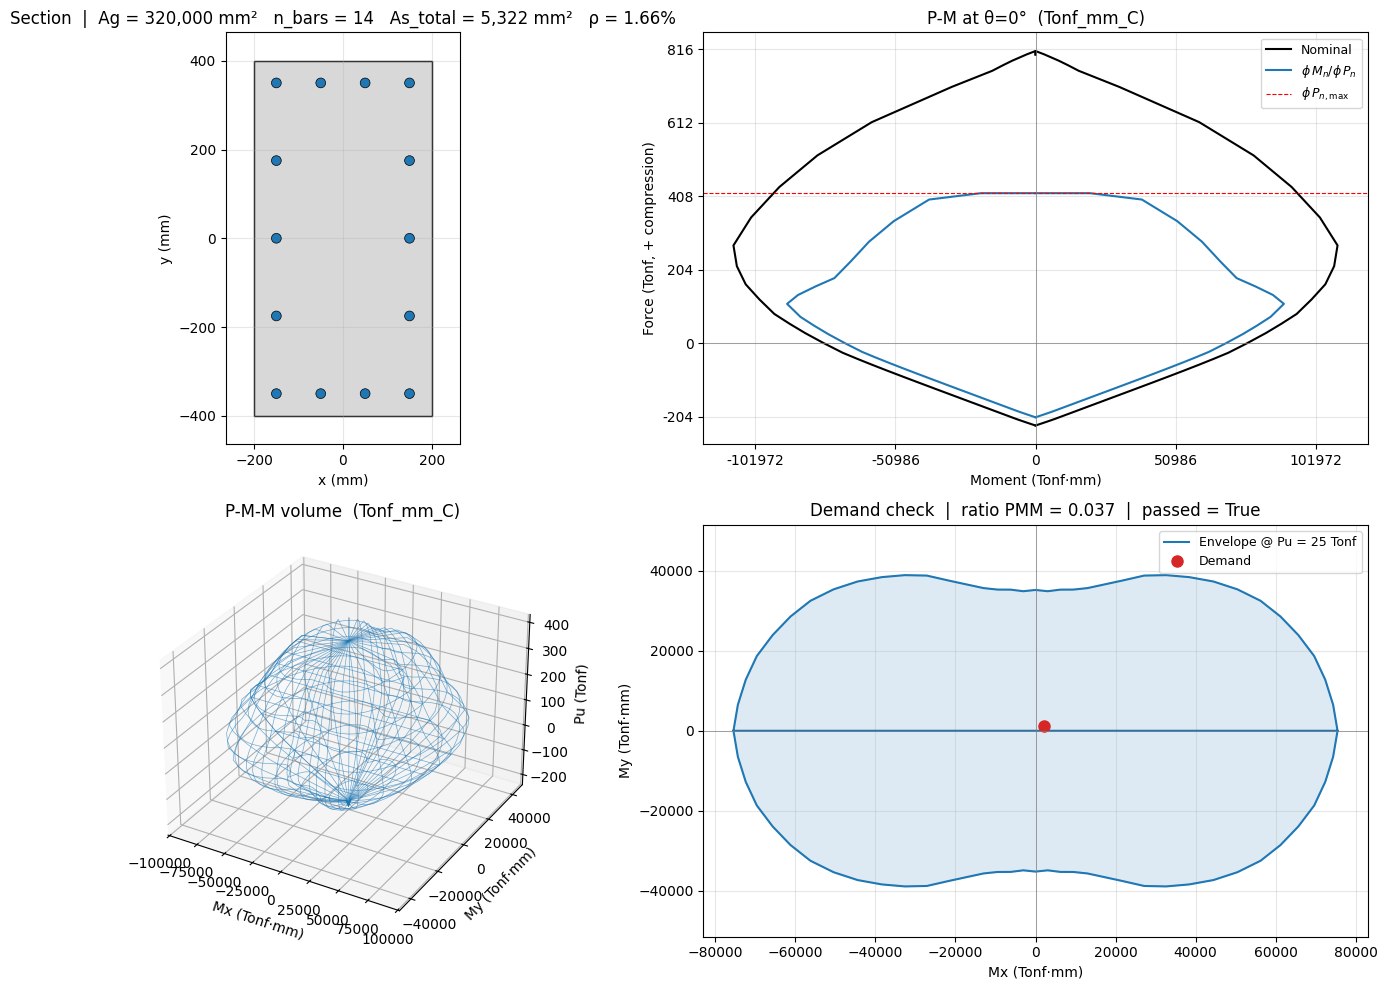

In [18]:
fig = column.plot.dashboard(demands=demands)
plt.show()

## 18. Plot — customize colors and style

Everything in `col.plot.style` is editable. Affects future plot calls; per-call kwargs override.

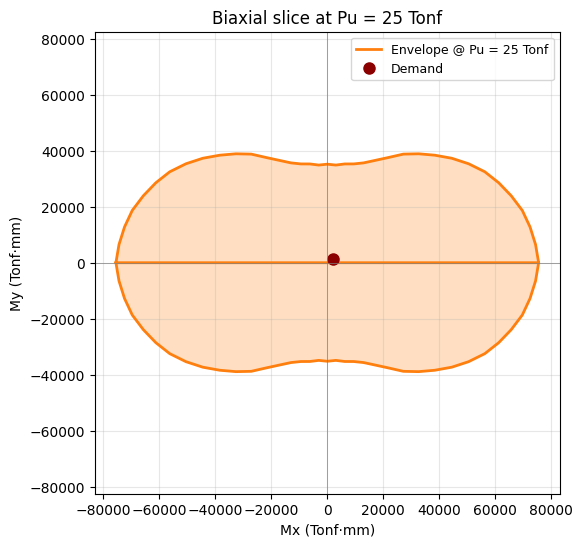

In [19]:
column.plot.style.color_reduced  = 'tab:orange'
column.plot.style.color_demand   = 'darkred'
column.plot.style.linewidth      = 2.0
column.plot.style.fill_alpha     = 0.25

fig, ax = plt.subplots(figsize=(6, 6))
column.plot.pmm_slice(Pu=demands.Pu,
                      demand=(demands.Mux, demands.Muy),
                      ax=ax)
plt.show()

## 19. Design — three modes in one call

`col.design(demands)` always runs **three modes** and returns a `ColumnDesignResults` container:

| Mode | What drives it |
|---|---|
| `results.minimum`  | ACI 318-25 §18.7.5.4 eqs (i) and (ii) only — no axial input |
| `results.demand`   | adds eq (iii) using `demands.Pu`. `None` if no `demands` passed |
| `results.capacity` | capacity design: eq (iii) with `Pu = Po`, plus Mpr and Ve per §18.7.6 |
| `results.envelope` | pointwise worst of the three |

The whole result also stays cached on `col.design_results` for later access.

`bar_schedule.hoops` and `bar_schedule.longitudinal` are editable lists that drive auto-selection of `db_hoop`.

In [20]:
print(f'bar_schedule.hoops        = {column.bar_schedule.hoops}')
print(f'bar_schedule.longitudinal = {column.bar_schedule.longitudinal}')
print()

results = column.design(demands)
print(type(results).__name__)
print(f'  results.minimum  → mode = {results.minimum.mode}')
print(f'  results.demand   → mode = {results.demand.mode if results.demand else None}')
print(f'  results.capacity → mode = {results.capacity.mode}')
print(f'  results.envelope → mode = {results.envelope.mode}')
print()
print(f'results is results : {results is results}')

bar_schedule.hoops        = [10, 12, 16]
bar_schedule.longitudinal = [12, 16, 20, 22, 25, 28, 32]

ColumnDesignResults
  results.minimum  → mode = minimum
  results.demand   → mode = demand
  results.capacity → mode = capacity
  results.envelope → mode = envelope

col.design_results is results : True


## 20. Compare the three modes side by side

In [21]:
header = (f'{"mode":<10} {"db":>4} {"legs":>9} {"Ash_x":>7} {"Ash_y":>7} '
          f'{"φVn_x":>7} {"φVn_y":>7} {"Ve_cap":>7} {"Ve/φVn":>7}')
print(header)
print('-' * len(header))
for label in ['minimum', 'demand', 'capacity', 'envelope']:
    p = getattr(results, label)
    if p is None: continue
    legs = f'({p.n_legs_x},{p.n_legs_y})'
    ve_ratio = max(p.ratio_Ve_over_phiVn_x or 0, p.ratio_Ve_over_phiVn_y or 0)
    print(f'{label:<10} φ{p.db_hoop:>3.0f} {legs:>9} '
          f'{p.ash_required_x:>7.0f} {p.ash_required_y:>7.0f} '
          f'{p.phi_Vn_x:>7.0f} {p.phi_Vn_y:>7.0f} '
          f'{p.Ve_capacity:>7.0f} {ve_ratio:>7.2f}')

mode         db  legs_x  legs_y  Ash_x req  Ash_y req  Av prov_x  Av prov_y    Pu_used  eq(iii)
-----------------------------------------------------------------------------------------------
minimum    φ 12       2       4        187        420        226        452          -    False
demand     φ 12       2       4        187        420        226        452        250    False
capacity   φ 16       2       4        374        841        402        804       7852     True
envelope   φ 16       2       4        374        841        402        804       7852     True


## 21. Capacity-design specifics — Mpr and Ve

Only `results.capacity` (and `results.envelope`) populate the Mpr / Ve fields. They use `fy_pr = 1.25·fy` and `φ = 1.0` to read the **probable** moment.

- `Mpr_top`, `Mpr_bot`: maximum probable moment over the Pu sweep (top = bot here, single-curvature assumption).
- `Ve_capacity = (Mpr_top + Mpr_bot) / lu`, capped by `Ωo · Vu_demand` if demands are given (§18.7.6.1.1).
- `amplification_vs_demand = Ve_capacity / Vu_demand`.

In [22]:
cap = results.capacity
print('Mode:', cap.mode)
print(f'  Pu_used (for eq iii)     = {cap.Pu_used:.0f} kN   →  Pu/(Ag·fc) = {cap.Pu_over_Ag_fc:.3f}')
print(f'  eq(iii) active           = {cap.eq_iii_active}')
print(f'  Mpr_top / Mpr_bot        = {cap.Mpr_top:.1f} / {cap.Mpr_bot:.1f} kN·m')
print(f'  Pu at peak Mpr           = {cap.Pu_for_Mpr:.0f} kN')
print(f'  Ve_capacity (uncapped)   = {cap.Ve_capacity:.1f} kN  (= (Mpr_top+Mpr_bot)/lu)')
if cap.Ve_used is not None:
    print(f'  Ve_used (after Ωo·Vu)    = {cap.Ve_used:.1f} kN')
if cap.amplification_vs_demand is not None:
    print(f'  amplif vs Vu_demand      = {cap.amplification_vs_demand:.2f}x')
print(f'  Av/s required for Ve     = {cap.av_s_required:.4f} mm²/mm')
print(f'  Av/s provided            = {cap.av_s_provided:.4f} mm²/mm')
print(f'  ratio shear              = {cap.ratio_shear:.2f}')
print()
print(f'  Proposed φVn_x / φVn_y   = {cap.phi_Vn_x:.0f} / {cap.phi_Vn_y:.0f} kN')
print(f'  Ve_capacity / φVn (X/Y)  = {cap.ratio_Ve_over_phiVn_x:.2f} / {cap.ratio_Ve_over_phiVn_y:.2f}')
for note in cap.notes:
    print(f'  • {note}')

Mode: capacity
  Pu_used (for eq iii)   = 7852 kN   →  Pu/(Ag·fc) = 1.168
  eq(iii) active         = True
  Mpr_top / Mpr_bot      = 1184.5 / 1184.5 kN·m
  Pu at peak Mpr         = 2348 kN
  Ve_capacity            = 45.0 kN  (= (Mpr_top+Mpr_bot)/lu)
  amplif vs Vu_demand    = 3.0x
  Av/s required for Ve   = 0.0000 mm²/mm
  Av/s provided          = 6.0319 mm²/mm
  ratio shear            = 0.00
  • Spacing in lo capped by §18.7.5.3.
  • No hoop in bar_schedule satisfied both physical-bar limit (max_x=5, max_y=4) and hx≤350; used max φ16.
  • n_legs_y=4 gives 804 mm² < 841 required.
  • Ve_capacity 790 kN capped by Ωo·Vu = 45 kN (§18.7.6.1.1).


## 22. Drill down into one mode — full report

In [23]:
def _fmt(x, fmt):
    return format(x, fmt) if x is not None else '-'

def print_proposal(p):
    print(f'=== mode = {p.mode} ===')
    print(f'  Ash_x req {p.ash_required_x:.0f}  prov {p.av_provided_x:.0f} mm² ({p.n_legs_x} legs φ{p.db_hoop:.0f})')
    print(f'  Ash_y req {p.ash_required_y:.0f}  prov {p.av_provided_y:.0f} mm² ({p.n_legs_y} legs φ{p.db_hoop:.0f})')
    print(f'  spacing in lo   = {p.spacing_confined:.0f} mm  (§18.7.5.3)')
    print(f'  spacing middle  = {p.spacing_middle:.0f} mm  (§18.7.5.5)')
    print(f'  lo (length)     = {p.lo:.0f} mm  (§18.7.5.1)')
    print(f'  hx X / Y face   = {p.hx_x_face:.0f} / {p.hx_y_face:.0f} mm   ok = {p.hx_ok}')
    if p.Pu_used is not None:
        print(f'  Pu_used         = {p.Pu_used:.0f} kN   eq(iii) active = {p.eq_iii_active}')
    if p.Vu_used is not None:
        print(f'  Vu_used         = {p.Vu_used:.0f} kN   '
              f'Av/s req = {_fmt(p.av_s_required, ".4f")}   '
              f'ratio = {_fmt(p.ratio_shear, ".2f")}')
    for n in p.notes:
        print(f'  • {n}')
    print()

print_proposal(results.minimum)
if results.demand is not None:
    print_proposal(results.demand)
print_proposal(results.capacity)
print_proposal(results.envelope)


=== mode = minimum ===
  Ash_x req 187  prov 226 mm² (2 legs φ12)
  Ash_y req 420  prov 452 mm² (4 legs φ12)
  spacing in lo   = 100 mm  (§18.7.5.3)
  spacing middle  = 120 mm  (§18.7.5.5)
  lo (length)     = 800 mm  (§18.7.5.1)
  hx X / Y face   = 320 / 240 mm   ok = True
  • Spacing in lo capped by §18.7.5.3.

=== mode = demand ===
  Ash_x req 187  prov 226 mm² (2 legs φ12)
  Ash_y req 420  prov 452 mm² (4 legs φ12)
  spacing in lo   = 100 mm  (§18.7.5.3)
  spacing middle  = 120 mm  (§18.7.5.5)
  lo (length)     = 800 mm  (§18.7.5.1)
  hx X / Y face   = 320 / 240 mm   ok = True
  Pu_used         = 250 kN   eq(iii) active = False
  Vu_used         = 15 kN   Av/s req = 0.0000   ratio = 0.00
  • Spacing in lo capped by §18.7.5.3.

=== mode = capacity ===
  Ash_x req 374  prov 402 mm² (2 legs φ16)
  Ash_y req 841  prov 804 mm² (4 legs φ16)
  spacing in lo   = 100 mm  (§18.7.5.3)
  spacing middle  = 120 mm  (§18.7.5.5)
  lo (length)     = 800 mm  (§18.7.5.1)
  hx X / Y face   = 320 / 240 

## 23. Manual override — same three-mode flow with your detailing

All kwargs of `col.design(...)`:

| kwarg | meaning |
|---|---|
| `db_hoop` | force a hoop diameter (skip bar_schedule auto-pick) |
| `n_legs_x` | force legs parallel to X |
| `n_legs_y` | force legs parallel to Y |
| `db_long_min` | smallest longitudinal bar — drives §18.7.5.5 spacing |
| `cover_to_hoop_center` | core dimension (mm) |

Overrides apply to all three modes.

In [24]:
results_manual = column.design(
    demands,
    db_hoop=10,
    n_legs_x=2,
    n_legs_y=2,
    db_long_min=14,
    clear_cover=25,
)

for label in ['minimum', 'demand', 'capacity', 'envelope']:
    p = getattr(results_manual, label)
    if p is None: continue
    print(f'{label:<10} φ{p.db_hoop:.0f}  legs=({p.n_legs_x},{p.n_legs_y})  '
          f'Av=({p.av_provided_x:.0f},{p.av_provided_y:.0f}) vs req=({p.ash_required_x:.0f},{p.ash_required_y:.0f})')
    for n in p.notes:
        print(f'              • {n}')

minimum    φ10  legs=(2,2)  Av=(157,157) vs req=(177,406)
              • Spacing in lo capped by §18.7.5.3.
              • n_legs_x=2 gives 157 mm² < 177 required.
              • n_legs_y=2 gives 157 mm² < 406 required.
              • hx > 350 mm on at least one face (X face: 310, Y face: 710).
demand     φ10  legs=(2,2)  Av=(157,157) vs req=(177,406)
              • Spacing in lo capped by §18.7.5.3.
              • n_legs_x=2 gives 157 mm² < 177 required.
              • n_legs_y=2 gives 157 mm² < 406 required.
              • hx > 350 mm on at least one face (X face: 310, Y face: 710).
capacity   φ10  legs=(2,2)  Av=(157,157) vs req=(304,697)
              • Spacing in lo capped by §18.7.5.3.
              • n_legs_x=2 gives 157 mm² < 304 required.
              • n_legs_y=2 gives 157 mm² < 697 required.
              • hx > 350 mm on at least one face (X face: 310, Y face: 710).
              • Ve_capacity 790 kN capped by Ωo·Vu = 45 kN (§18.7.6.1.1).
envelope   φ10  legs=(2,2)

### 23b. Sweep hoop diameters and inspect the envelope

For each hoop diameter, show what the envelope mode picks.

In [25]:
print(f'{"db_hoop":>8} {"legs_x":>7} {"legs_y":>7} {"Av_x":>8} {"Av_y":>8}  {"Ve_cap":>9}  {"hx_ok":>6}')
for db in column.bar_schedule.hoops:
    r = column.design(demands, db_hoop=db)
    e = r.envelope
    ve = f'{r.capacity.Ve_capacity:.0f}' if r.capacity.Ve_capacity else '-'
    print(f'{db:>8.0f} {e.n_legs_x:>7d} {e.n_legs_y:>7d} '
          f'{e.av_provided_x:>8.0f} {e.av_provided_y:>8.0f}  {ve:>9}  {str(e.hx_ok):>6}')

 db_hoop  legs_x  legs_y     Av_x     Av_y     Ve_cap   hx_ok
      10       5       4      393      314         45    True
      12       4       4      452      452         45    True
      16       2       4      402      804         45   False


## 24. Report — structured dict (display units applied)

In [26]:
from pprint import pprint
pprint(column.report())

{'capacity': {'Po': 800.6998859619429,
              'To': -227.92491567826934,
              'max_phi_Mn_x': 90462.77102494788,
              'max_phi_Mn_y': 42535.18578924332,
              'phi_Pn_max': 416.3639407002104,
              'phi_Vn': 49.999548990617065},
 'label': 'Col-1A',
 'materials': {'fc_MPa': 21, 'fy_MPa': 420},
 'params': {'fyt_MPa': 420.0,
            'hx_mm': 150.0,
            'k': 1.0,
            'lu_m': 3.0,
            's_mm': 100.0,
            'seismic': True,
            'spiral': False},
 'rebar': {'As': 5321.85795518111, 'n_bars': 14, 'rho': 0.016630806109940968},
 'section': {'Ag': 320000.0, 'b': 400.0, 'h': 800.0},
 'units': 'Tonf_mm_C'}


## 25. Change units on the fly — everything updates

In [27]:
for code in [5, 6, 11, 12, 13, 16]:
    column.set_units(code)
    u = column.units
    print(f'code={u.code:>2}  ({u.name:>10})   Po = {column.Po*u.force_factor:>8.1f} {u.force}'
          f'   max φMn @ 0° = {max(column.surface[0].phi_Mn)*u.moment_factor:>10.1f} {u.force}·{u.length}')
column.set_units(11)
print(f'\nrestored units = {column.units.name}')

code= 5  (   kN_mm_C)   Po =   7852.2 kN   max φMn @ 0° =   887136.9 kN·mm
code= 6  (    kN_m_C)   Po =   7852.2 kN   max φMn @ 0° =      887.1 kN·m
code=11  ( Tonf_mm_C)   Po =    800.7 Tonf   max φMn @ 0° =    90462.8 Tonf·mm
code=12  (  Tonf_m_C)   Po =    800.7 Tonf   max φMn @ 0° =       90.5 Tonf·m
code=13  (   kN_cm_C)   Po =   7852.2 kN   max φMn @ 0° =    88713.7 kN·cm
code=16  ( Tonf_cm_C)   Po =    800.7 Tonf   max φMn @ 0° =     9046.3 Tonf·cm

restored units = Tonf_mm_C


## 26. Adopt a proposal — `col.apply(proposal)`

`col.apply(p)` updates the column with the proposed transverse reinforcement (db_hoop, n_legs, spacing) **inplace**. After applying, `col.phi_Vn` reflects the new detailing. The PMM surface is not rebuilt — it only depends on longitudinal reinforcement.

In [ ]:
print(f'Before apply: col.phi_Vn = {column.phi_Vn:.0f} kN, col.Av = {column.Av:.0f}, col.s = {column.s}')

column = column.apply(results.envelope)
print(f'After  apply: col.phi_Vn = {column.phi_Vn:.0f} kN, col.Av = {column.Av:.0f}, col.s = {column.s}')
print(f'              col.transverse_bar_diameter = {column.transverse_bar_diameter:.0f} mm')

## 27. Optimize — alternatives around the design() baseline

`col.run_optimize(demands)` starts from the design envelope (the `is_baseline=True` row) and explores every other feasible `(db_hoop × n_legs_x × n_legs_y)` combination from the bar schedule and the physical bar-count limit. Only alternatives that pass Ash + hx are reported (pass `include_infeasible=True` to also see the rest).

All quantities are in **kg/m³ of concrete**:

| Column | Meaning |
|---|---|
| `ρ_trans` | hoops only, in 1 m of the lo region |
| `ρ_long` | longitudinal bars, constant across alternatives |
| `ρ_total` | sum |
| `baseline` | the original design() pick — always included for comparison |

Sort is by `ρ_total` ascending — the lightest entry is the optimum.

In [ ]:
alts = column.run_optimize(demands)

print(f'{"rank":>4} {"db":>4} {"legs_x":>6} {"legs_y":>6} '
      f'{"ρ_trans":>11} {"ρ_long":>11} {"ρ_total":>11}  baseline')
print(f'{"":>4} {"":>4} {"":>6} {"":>6} '
      f'{"(kg/m³)":>11} {"(kg/m³)":>11} {"(kg/m³)":>11}')
print('-' * 75)
for i, a in enumerate(alts[:10], 1):
    mark = ' ←' if a.is_baseline else ''
    print(f'{i:>4} φ{a.db_hoop:>3.0f} {a.n_legs_x:>6d} {a.n_legs_y:>6d}'
          f' {a.rho_transverse:>11.1f} {a.rho_longitudinal:>11.1f} {a.rho_total:>11.1f}'
          f' {str(a.is_baseline):>8}{mark}')

best = alts[0]
print()
print(f'Lightest: φ{best.db_hoop:.0f}, legs=({best.n_legs_x},{best.n_legs_y}), '
      f's={best.proposal.spacing_confined:.0f} mm, ρ_total = {best.rho_total:.1f} kg/m³')
if best.is_baseline:
    print('  → the design() baseline is already the lightest feasible.')
else:
    print(f'  → a lighter alternative was found vs. baseline.')